In [1]:
import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import re
import copy

from sklearn.model_selection import train_test_split

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("amiadesu/ukrainian-social-spam")
data = pd.read_csv('C:/Users/User/.cache/kagglehub/datasets/amiadesu/ukrainian-social-spam/versions/2/spam.csv')

copy_data = copy.deepcopy(data)

# print(data.head())
print(copy_data.head())

                                                text  spam
0  __USER__ Це лека, і вона дуже крута, вона наша...     0
1  У другому турі підтримав Віктора Ющенка, поста...     0
2  🪖 Твоя ідеальна підробітка? Знайдена. Без босі...     1
3  🔹 ВАКАНСІЯ | АДМІНІСТРАТОР у центрі протезуван...     1
4                  __USER__ Відміть мене коли зможеш     0


In [3]:
# Аналіз Dataset
print('**Загальна інформація про Dataset:**')
data.info()

print('\n**Кількість унікальних значень цільової змінної:**\n', data.nunique())

**Загальна інформація про Dataset:**
<class 'pandas.DataFrame'>
RangeIndex: 91386 entries, 0 to 91385
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    91386 non-null  str  
 1   spam    91386 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.4 MB

**Кількість унікальних значень цільової змінної:**
 text    91386
spam        2
dtype: int64


In [4]:
# Співвідношення spam / not-spam
data['spam'].value_counts(normalize=True) * 100

spam
0    71.307421
1    28.692579
Name: proportion, dtype: float64

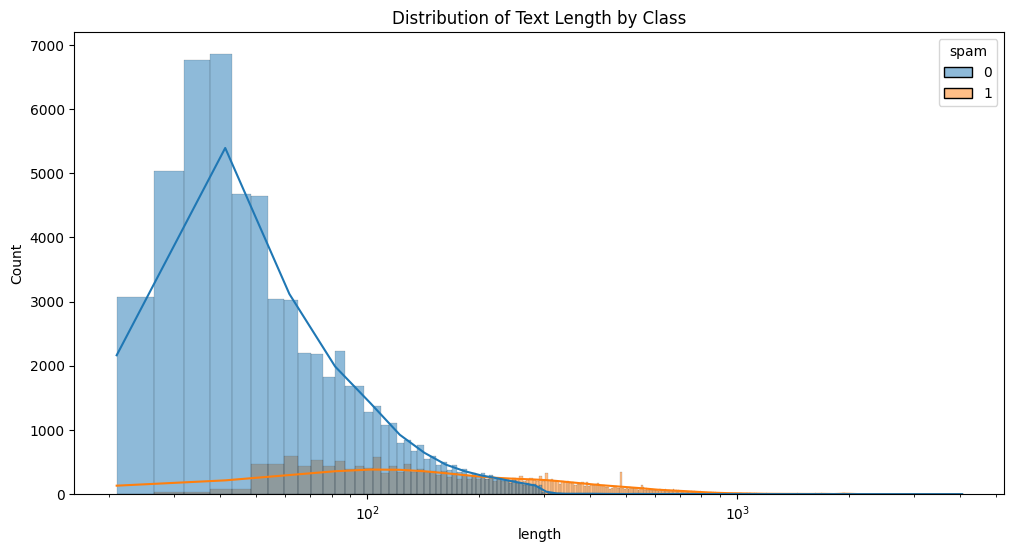

In [22]:
# Проста візуалізація розподілу
copy_data["length"] = copy_data["text"].str.len()
plt.figure(figsize=(12,6))

sns.histplot(
    data=copy_data,
    x="length",
    hue="spam",
    kde=True
)

plt.xscale("log")
plt.title("Distribution of Text Length by Class")
plt.show()

In [6]:
# Аналіз текстів
word_counts = sum(len(msg.split()) for msg in data['text'])
avg_length_word = word_counts / len(data['text'])
print('Середня довжина повідомлення у словах:', avg_length_word)

symbols_counts = sum(len(msg) for msg in data['text'])
avg_length_symbols = symbols_counts / len(data['text'])
print('Середня довжина повідомлення у символах:', avg_length_symbols)

spam_text = data[data['spam'] == 1]['text']
normal_text = data[data['spam'] == 0]['text']
spam_words = " ".join(spam_text).split()
normal_words = " ".join(normal_text).split()
frequency_words_spam = Counter(spam_words)
frequency_words_normal = Counter(normal_words)
print('\nЧастотні спам слова:', frequency_words_spam.most_common(3))
print('Частотні не спам слова:', frequency_words_normal.most_common(3))

# if data['text'].str.contains("http://|https://").any():
#     print("\nЗнайдено посилання")
# else:
#     print("\nПосилань не знайдено")

url_pattern = r'https?://\S+'
if data['text'].str.contains(url_pattern, regex=True).any():
    texts_with_links = data[data['text'].str.contains(url_pattern, regex=True)]
    print(f'\nЗнайдено посилання у тексті у кількості {len(texts_with_links)} шт.:\n', texts_with_links)
else:
    print("\nПосилань у тексті не знайдено")

emoji_pattern = r'[^\w\s,.]'
if data['text'].str.contains(emoji_pattern, regex=True).any():
    texts_with_emoji = data[data['text'].str.contains(emoji_pattern, regex=True)]
    print(f'\nЗнайдено емодзі у тексті в кількості {len(texts_with_emoji)} шт.:\n',  texts_with_emoji)
else:
    print("\Емодзі не знайдено")

upper_pattern = r'\b[А-Я]+\b'
if data['text'].str.contains(upper_pattern, regex=True).any():
    texts_with_upper = data[data['text'].str.contains(upper_pattern, regex=True)]
    print(f'\nЗнайдено велику кількість великих літер у тексті у кількості {len(texts_with_upper)} шт.:\n', texts_with_upper)
else:
    print("\nВелику кількість великих літер у тексті не знайдено")

Середня довжина повідомлення у словах: 24.56692491191211
Середня довжина повідомлення у символах: 154.01868995250913

Частотні спам слова: [('__URL__', 23411), ('грн', 22281), ('на', 21988)]
Частотні не спам слова: [('__USER__', 15491), ('в', 15176), ('на', 13717)]

Посилань у тексті не знайдено

Знайдено емодзі у тексті в кількості 54336 шт.:
                                                     text  spam
1      У другому турі підтримав Віктора Ющенка, поста...     0
2      🪖 Твоя ідеальна підробітка? Знайдена. Без босі...     1
3      🔹 ВАКАНСІЯ | АДМІНІСТРАТОР у центрі протезуван...     1
5      __USER__ ну короче, чи може моя подруга з Поль...     0
7      ✅️ ЗА ФОТО 160 ГРН ✅️ ✅️ Вивела 2440 грн з цьо...     1
...                                                  ...   ...
91372  🌿🌿🌿🌿🌿🌿🌿🌿🌿🌿🌿🌿🌿 ⭐✨ ВИЙШОВ НОВИЙ БОТ ✨⭐ 🦋🦋🔥 НАЙКР...     1
91374  не сказала б: маю хлопців і 20+ років, і 40+ р...     0
91377  1️⃣2️⃣.0️⃣8️⃣.2️⃣0️⃣2️⃣5️⃣ Вітаємо🥰 🙋‍♀️ Приєд...     1
91379  📣 Оператор верст

In [12]:
# Розділення даних на train/test вибірку
X = data['text']
y = data['spam']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # для збереження пропорцій класів при поділі даних (тому що є невеликий дисбаланс класів)
)